In [1]:
import sys
import transformers

print("Python:", sys.executable)
print("Transformers:", transformers.__version__)
print("Transformers 경로:", transformers.__file__)

from transformers import Sam2Model, Sam2Processor
print("SAM2 import 성공")

Python: /opt/conda/envs/final/bin/python
Transformers: 5.12.1
Transformers 경로: /opt/conda/envs/final/lib/python3.11/site-packages/transformers/__init__.py
SAM2 import 성공


In [2]:
%matplotlib widget

In [3]:
import torch
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from transformers import Sam2Model, Sam2Processor
import ipywidgets as widgets
from IPython.display import display

### 모델 초기화 코드
1번만 초기화하면 된다.

In [9]:
MODEL_ID = "facebook/sam2.1-hiera-large"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

processor = Sam2Processor.from_pretrained(MODEL_ID)

model = Sam2Model.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16 if DEVICE == "cuda" else torch.float32,
).to(DEVICE)

[transformers] You are using a model of type `sam2_video` to instantiate a model of type `sam2`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


Loading weights:   0%|          | 0/741 [00:00<?, ?it/s]

### 2. 모델 로드

In [12]:
processor = Sam2Processor.from_pretrained(MODEL_ID)
model = Sam2Model.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
).to(DEVICE)

model.eval()

[transformers] You are using a model of type `sam2_video` to instantiate a model of type `sam2`. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.


Loading weights:   0%|          | 0/741 [00:00<?, ?it/s]

Sam2Model(
  (shared_image_embedding): Sam2PositionalEmbedding()
  (vision_encoder): Sam2VisionModel(
    (backbone): Sam2HieraDetModel(
      (patch_embed): Sam2PatchEmbeddings(
        (projection): Conv2d(3, 144, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
      )
      (blocks): ModuleList(
        (0-1): 2 x Sam2MultiScaleBlock(
          (layer_norm1): LayerNorm((144,), eps=1e-06, elementwise_affine=True)
          (attn): Sam2MultiScaleAttention(
            (qkv): Linear(in_features=144, out_features=432, bias=True)
            (proj): Linear(in_features=144, out_features=144, bias=True)
          )
          (layer_norm2): LayerNorm((144,), eps=1e-06, elementwise_affine=True)
          (mlp): Sam2FeedForward(
            (activation): GELUActivation()
            (proj_in): Linear(in_features=144, out_features=576, bias=True)
            (proj_out): Linear(in_features=576, out_features=144, bias=True)
            (layers): ModuleList()
          )
        )
        (2):

In [13]:
log_out = widgets.Output()
display(log_out)

def load_image(image_path):
    return Image.open(image_path).convert("RGB")

"""
입력 포인트를 기반으로 segmentation mask 예측
"""
def predict_mask(raw_image, point_xy, point_labels, multimask_output=False):
    input_points = [[[[float(x), float(y)] for x, y in point_xy]]]
    input_labels = [[[int(label) for label in point_labels]]]

    inputs = processor(
        images=raw_image,
        input_points=input_points,
        input_labels=input_labels,
        return_tensors="pt"
    )

    inputs = {k: v.to(DEVICE) if hasattr(v, "to") else v for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs, multimask_output=multimask_output)

    masks = processor.post_process_masks(
        outputs.pred_masks.cpu(),
        inputs["original_sizes"].cpu()
    )

    scores = outputs.iou_scores.cpu().numpy()

    # numpy로 변환
    mask_array = masks[0]
    if hasattr(mask_array, "numpy"):
        mask_array = mask_array.numpy()

    # 디버깅용
    print("raw mask_array shape:", mask_array.shape)
    print("scores shape:", scores.shape)

    # 앞쪽 singleton 차원 제거
    mask_array = np.squeeze(mask_array)

    print("squeezed mask_array shape:", mask_array.shape)

    # multimask_output=False 면 보통 여기서 (H, W)가 되어야 함
    # 혹시 still 3D면 첫 번째 mask 선택
    if mask_array.ndim == 3:
        mask = mask_array[0]
    elif mask_array.ndim == 2:
        mask = mask_array
    else:
        raise ValueError(f"Unexpected mask shape after squeeze: {mask_array.shape}")

    return mask.astype(bool), scores

Output()

In [14]:
"""
예측된 mask와 클릭 포인트를 이미지 위에 시각화
"""
def overlay_mask(ax, image_np, mask, points_xy=None, point_labels=None, alpha=0.5):
    mask = np.asarray(mask)
    mask = np.squeeze(mask)

    if mask.ndim != 2:
        raise ValueError(f"mask must be 2D, got shape={mask.shape}")

    ax.clear()
    ax.imshow(image_np)

    overlay = np.zeros((mask.shape[0], mask.shape[1], 4), dtype=np.float32)
    overlay[..., 1] = 1.0
    overlay[..., 3] = mask.astype(np.float32) * alpha
    ax.imshow(overlay)

    # if points_xy is not None and point_labels is not None:
    #     for i, (x, y) in enumerate(points_xy):
    #         color = "red" if point_labels[i] == 1 else "blue"
    #         ax.scatter(x, y, s=80, marker="*", c=color)

    ax.set_axis_off()
    ax.figure.canvas.draw_idle()

In [17]:
from pathlib import Path

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from PIL import Image


class InteractiveSAM2Segmenter:
    def __init__(self, image_path, save_path):
        """
        이미지 및 인터랙션 화면 초기화
        """
        self.raw_image = load_image(image_path)
        self.image_np = np.array(self.raw_image)

        self.save_path = Path(save_path)

        self.points_xy = []
        self.point_labels = []

        # 가장 최근 segmentation 결과 보관
        self.current_mask = None

        self.fig, self.ax = plt.subplots(figsize=(10, 8))
        self.ax.imshow(self.image_np)
        self.ax.set_title(
            "Left click: positive / Right click: negative / r: reset"
        )
        self.ax.set_axis_off()

        self.cid_click = self.fig.canvas.mpl_connect(
            "button_press_event",
            self.on_click
        )
        self.cid_key = self.fig.canvas.mpl_connect(
            "key_press_event",
            self.on_key
        )

        # 저장 버튼
        self.save_button = widgets.Button(
            description="마스크 저장",
            button_style="success",
            icon="save"
        )
        self.save_button.on_click(self.on_save_button_clicked)

        # 상태 표시
        self.status_output = widgets.Output()

        display(
            widgets.HBox([self.save_button]),
            self.status_output
        )

        plt.show()

    def redraw_original(self):
        """
        현재 포인트를 반영해 원본 이미지 다시 그리기
        """
        self.ax.clear()
        self.ax.imshow(self.image_np)

        for i, (x, y) in enumerate(self.points_xy):
            color = "red" if self.point_labels[i] == 1 else "blue"
            self.ax.scatter(
                x,
                y,
                s=80,
                marker="*",
                c=color
            )

        self.ax.set_title(
            "Left click: positive / Right click: negative / r: reset"
        )
        self.ax.set_axis_off()
        self.fig.canvas.draw_idle()

    def save_binary_mask(self, mask, save_path):
        """
        마스킹 영역은 흰색, 나머지는 검정색으로 저장
        """
        mask = np.asarray(mask)
        mask = np.squeeze(mask)

        if mask.ndim != 2:
            raise ValueError(
                f"예상하지 못한 mask shape: {mask.shape}"
            )

        binary_mask = (mask > 0).astype(np.uint8) * 255

        save_path = Path(save_path)
        save_path.parent.mkdir(
            parents=True,
            exist_ok=True
        )

        Image.fromarray(
            binary_mask,
            mode="L"
        ).save(save_path)

    def on_click(self, event):
        """
        클릭 좌표를 저장하고 segmentation 수행
        """
        if event.inaxes != self.ax:
            return

        if event.xdata is None or event.ydata is None:
            return

        x = int(event.xdata)
        y = int(event.ydata)

        if event.button == 1:
            label = 1
        elif event.button == 3:
            label = 0
        else:
            return

        self.points_xy.append((x, y))
        self.point_labels.append(label)

        # with self.status_output:
        #     print(f"clicked: ({x}, {y}), label={label}")

        try:
            mask, scores = predict_mask(
                self.raw_image,
                self.points_xy,
                self.point_labels,
                multimask_output=False
            )

            # 최신 마스크만 메모리에 저장
            self.current_mask = mask

            overlay_mask(
                self.ax,
                self.image_np,
                mask,
                self.points_xy,
                self.point_labels
            )

            # with self.status_output:
            #     print("segmentation success")
            #     print("scores:", scores)
            #     print("저장하려면 '마스크 저장' 버튼을 누르세요.")

        except Exception as e:
            with self.status_output:
                print("segmentation error:", repr(e))

    def on_save_button_clicked(self, button):
        """
        저장 버튼을 눌렀을 때 최신 마스크 저장
        """
        self.status_output.clear_output()

        if self.current_mask is None:
            with self.status_output:
                print("저장할 마스크가 없습니다.")
                print("먼저 이미지 위를 클릭해 segmentation을 수행하세요.")
            return

        try:
            self.save_binary_mask(
                self.current_mask,
                self.save_path
            )

            with self.status_output:
                print(f"마스크 저장 완료: {self.save_path}")

        except Exception as e:
            with self.status_output:
                print("마스크 저장 오류:", repr(e))

    def on_key(self, event):
        """
        리셋 키 입력 처리
        """
        if event.key == "r":
            self.points_xy = []
            self.point_labels = []
            self.current_mask = None

            self.redraw_original()

            with self.status_output:
                print("reset")

In [18]:
"""
이미지 경로 입력
"""
IMAGE_PATH = widgets.Text(
    value='',
    placeholder='예. ../images/sheep.png',
    description='Image:'
)

display(IMAGE_PATH)

Text(value='', description='Image:', placeholder='예. ../images/sheep.png')

Output()

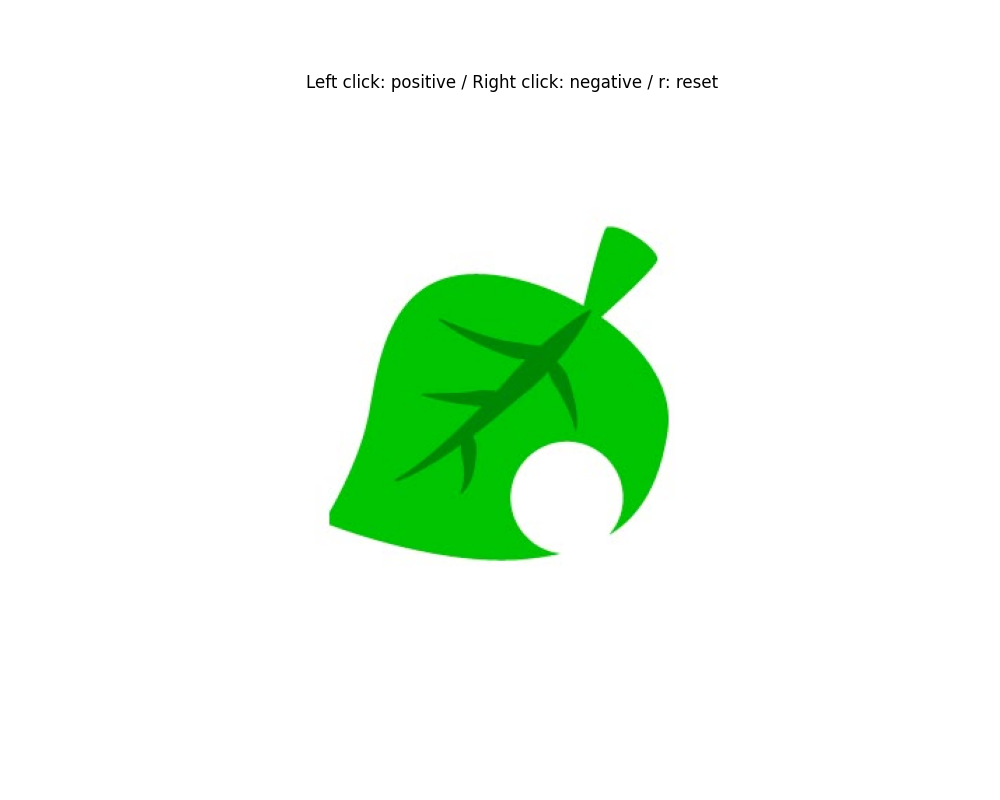

In [9]:
img = IMAGE_PATH.value

segmenter = InteractiveSAM2Segmenter(img, "/workspace/DL/assets/leaf.png")